# XGBoost (Extreme Gradient Boosting)

## Overview
XGBoost is an optimized, regularized implementation of Gradient Boosting that is faster, more scalable, and often more accurate than sklearn's GradientBoosting. It won numerous Kaggle competitions and is one of the most widely used ML algorithms.

### XGBoost Objective Function:
$$\mathcal{L} = \sum_{i=1}^{n} l(y_i, \hat{y}_i) + \sum_{k=1}^{K} \Omega(f_k)$$

Where the regularization term is:
$$\Omega(f) = \gamma T + \frac{1}{2}\lambda \sum_{j=1}^{T} w_j^2$$

- $T$ = number of leaves
- $w_j$ = leaf weight
- $\gamma$ = minimum gain to make a split
- $\lambda$ = L2 regularization on leaf weights

### Key Advantages over sklearn GB:
| Feature | sklearn GB | XGBoost |
|---------|-----------|--------|
| Speed | Slow | Fast (parallelized) |
| Regularization | None | L1 + L2 built-in |
| Missing values | Manual | Handles natively |
| Early stopping | Manual | Built-in |
| Tree method | Exact | Approx / Hist |
| Pruning | Post-pruning | Max-depth + gamma |

### Key Hyperparameters:
| Parameter | Role |
|-----------|------|
| `n_estimators` | Number of boosting rounds |
| `learning_rate` | Step size shrinkage |
| `max_depth` | Max tree depth (3-8 typical) |
| `subsample` | Row subsampling |
| `colsample_bytree` | Column subsampling per tree |
| `reg_alpha` | L1 regularization (Lasso) |
| `reg_lambda` | L2 regularization (Ridge) |
| `gamma` | Min loss reduction for split |

---
### Topics Covered
1. XGBoost installation check
2. Classification — fit and evaluate
3. Decision boundary
4. Early stopping
5. Feature importance (4 types)
6. Hyperparameter tuning with GridSearchCV
7. Regularization — alpha, lambda, gamma
8. XGBoost Regressor
9. Handling missing values natively
10. Real-world offline-safe dataset
11. DT vs RF vs GB vs XGBoost comparison


## 1. Import Libraries & Check XGBoost

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

try:
    import xgboost as xgb
    from xgboost import XGBClassifier, XGBRegressor
    print(f'XGBoost version : {xgb.__version__}')
except ImportError:
    print('XGBoost not found. Installing...')
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'])
    import xgboost as xgb
    from xgboost import XGBClassifier, XGBRegressor
    print(f'XGBoost installed and imported. Version: {xgb.__version__}')

from sklearn.ensemble import (
    GradientBoostingClassifier, RandomForestClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay,
    mean_squared_error, r2_score, mean_absolute_error
)
from sklearn.datasets import make_classification, make_regression

COLORS = {
    'primary':   '#2E86AB',
    'secondary': '#E67E22',
    'tertiary':  '#9B59B6',
    'success':   '#27AE60',
    'danger':    '#E74C3C',
    'neutral':   '#7F8C8D',
    'xgb':       '#E74C3C',
}

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('husl')

print('All libraries imported successfully!')
print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')

XGBoost not found. Installing...
XGBoost installed and imported. Version: 3.3.0
All libraries imported successfully!
NumPy  : 1.26.4
Pandas : 2.3.3


## 2. Classification — Generate Dataset & Fit XGBoost

In [2]:
np.random.seed(42)
X, y = make_classification(
    n_samples=700, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=2, class_sep=1.0, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

xgb_clf = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_clf.fit(X_train, y_train)

y_pred = xgb_clf.predict(X_test)
y_prob = xgb_clf.predict_proba(X_test)[:, 1]

print('=== XGBoost Classifier ===')
print(f'n_estimators      : {xgb_clf.n_estimators}')
print(f'learning_rate     : {xgb_clf.learning_rate}')
print(f'max_depth         : {xgb_clf.max_depth}')
print(f'subsample         : {xgb_clf.subsample}')
print(f'colsample_bytree  : {xgb_clf.colsample_bytree}')
print(f'Test Accuracy     : {accuracy_score(y_test, y_pred):.4f}')
print(f'Test ROC-AUC      : {roc_auc_score(y_test, y_prob):.4f}')
print(f'Test F1 Score     : {f1_score(y_test, y_pred):.4f}')

=== XGBoost Classifier ===
n_estimators      : 100
learning_rate     : 0.1
max_depth         : 4
subsample         : 0.8
colsample_bytree  : 0.8
Test Accuracy     : 0.8357
Test ROC-AUC      : 0.9089
Test F1 Score     : 0.8414


## 3. Decision Boundary Visualization

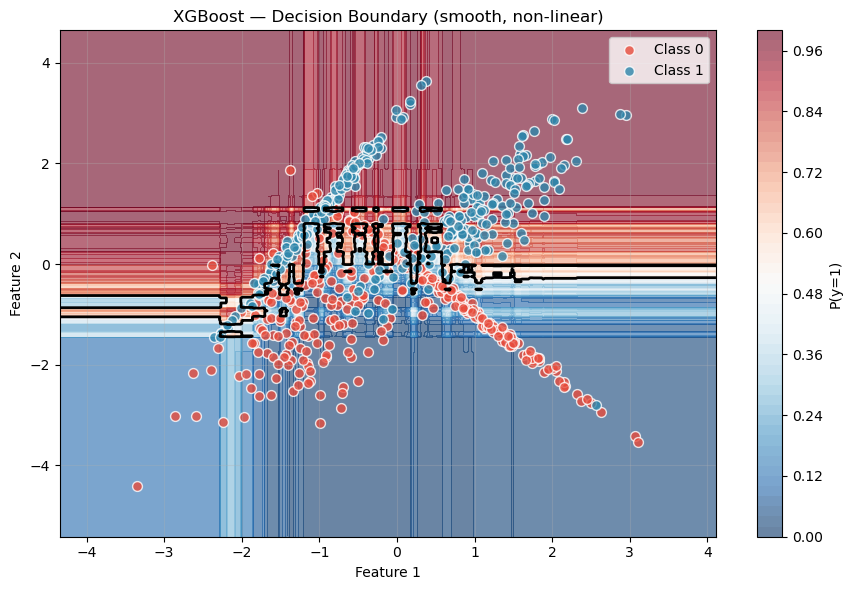

In [3]:
x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))
Z = xgb_clf.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

plt.figure(figsize=(9, 6))
plt.contourf(xx, yy, Z, levels=50, cmap='RdBu_r', alpha=0.6)
plt.colorbar(label='P(y=1)')
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
plt.scatter(X[y==0, 0], X[y==0, 1], color=COLORS['danger'],
            edgecolors='white', s=50, alpha=0.8, label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], color=COLORS['primary'],
            edgecolors='white', s=50, alpha=0.8, label='Class 1')
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.title('XGBoost — Decision Boundary (smooth, non-linear)')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Early Stopping — Finding Optimal n_estimators

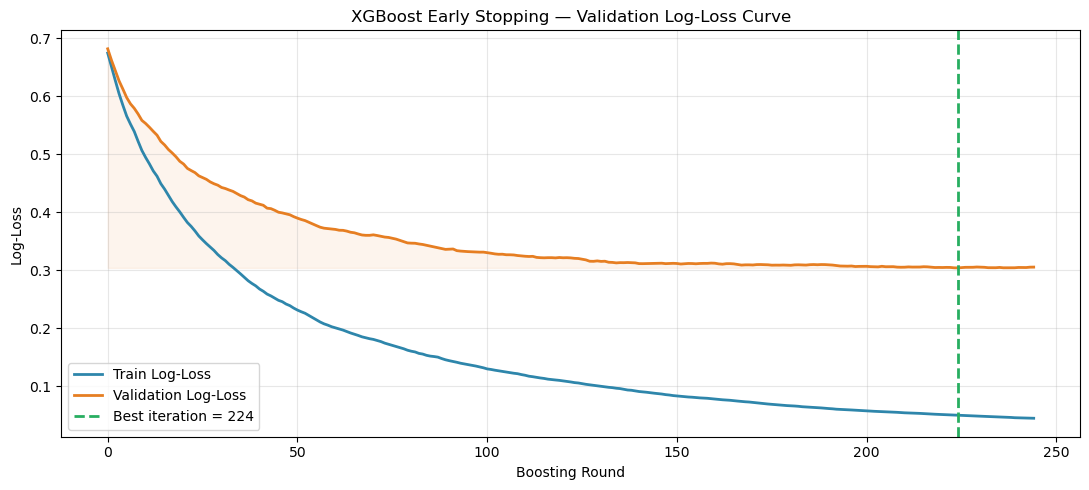

Best iteration (early stopping) : 224
Best validation log-loss        : 0.3044
Test Accuracy                   : 0.8875

Early stopping avoids overfitting without needing to pre-specify n_estimators.
Training stops when validation metric stops improving for early_stopping_rounds.


In [4]:
# Multi-feature dataset for a cleaner early stopping demo
np.random.seed(10)
X_es, y_es = make_classification(
    n_samples=800, n_features=20, n_informative=12,
    n_redundant=5, random_state=10
)
X_es_tr, X_es_te, y_es_tr, y_es_te = train_test_split(
    X_es, y_es, test_size=0.2, random_state=42, stratify=y_es
)
X_es_tr2, X_es_val, y_es_tr2, y_es_val = train_test_split(
    X_es_tr, y_es_tr, test_size=0.2, random_state=42, stratify=y_es_tr
)

xgb_es = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1
)
xgb_es.fit(
    X_es_tr2, y_es_tr2,
    eval_set=[(X_es_tr2, y_es_tr2), (X_es_val, y_es_val)],
    verbose=False
)

results   = xgb_es.evals_result()
train_log = results['validation_0']['logloss']
val_log   = results['validation_1']['logloss']
best_iter = xgb_es.best_iteration

plt.figure(figsize=(11, 5))
plt.plot(train_log, color=COLORS['primary'],   linewidth=2, label='Train Log-Loss')
plt.plot(val_log,   color=COLORS['secondary'], linewidth=2, label='Validation Log-Loss')
plt.axvline(best_iter, color=COLORS['success'], linestyle='--',
            linewidth=2, label=f'Best iteration = {best_iter}')
plt.fill_between(range(len(val_log)),
                 val_log, min(val_log),
                 alpha=0.08, color=COLORS['secondary'])
plt.xlabel('Boosting Round')
plt.ylabel('Log-Loss')
plt.title('XGBoost Early Stopping — Validation Log-Loss Curve')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Best iteration (early stopping) : {best_iter}')
print(f'Best validation log-loss        : {xgb_es.best_score:.4f}')
test_acc_es = accuracy_score(y_es_te, xgb_es.predict(X_es_te))
print(f'Test Accuracy                   : {test_acc_es:.4f}')
print()
print('Early stopping avoids overfitting without needing to pre-specify n_estimators.')
print('Training stops when validation metric stops improving for early_stopping_rounds.')

## 5. Feature Importance — 4 Types in XGBoost

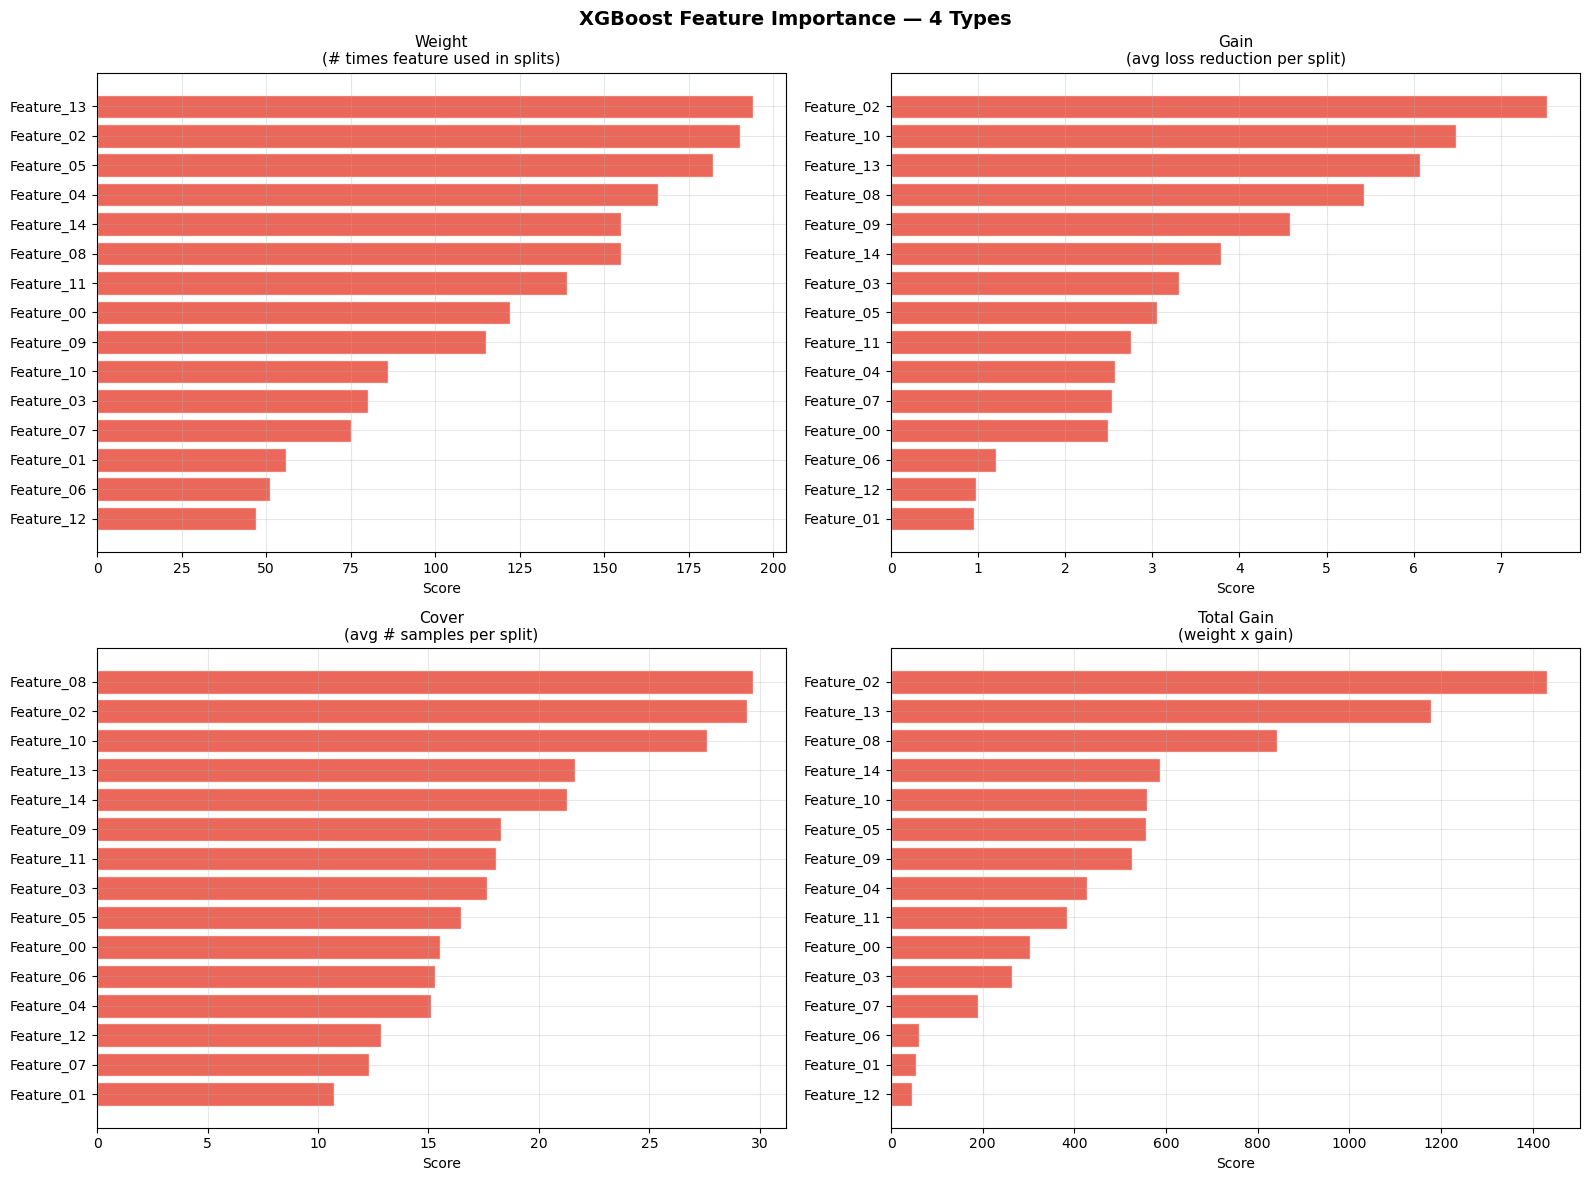

weight     : how often a feature is used in splits (can be biased)
gain       : avg improvement in loss when feature is used (most useful)
cover      : avg number of samples affected by splits on this feature
total_gain : gain x weight (overall contribution)


In [5]:
np.random.seed(7)
X_imp, y_imp = make_classification(
    n_samples=800, n_features=15, n_informative=8,
    n_redundant=4, random_state=7
)
feat_names = [f'Feature_{i:02d}' for i in range(15)]

X_imp_tr, X_imp_te, y_imp_tr, y_imp_te = train_test_split(
    X_imp, y_imp, test_size=0.2, random_state=42, stratify=y_imp
)

xgb_imp = XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb_imp.fit(X_imp_tr, y_imp_tr)

importance_types = ['weight', 'gain', 'cover', 'total_gain']
type_titles      = [
    'Weight\n(# times feature used in splits)',
    'Gain\n(avg loss reduction per split)',
    'Cover\n(avg # samples per split)',
    'Total Gain\n(weight x gain)'
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for ax, imp_type, title in zip(axes, importance_types, type_titles):
    scores = xgb_imp.get_booster().get_score(importance_type=imp_type)
    scores_full = {f: scores.get(f'f{feat_names.index(f) if f in feat_names else int(f[1:])}', 0)
                   for f in feat_names}
    scores_full = {fn: xgb_imp.get_booster().get_score(
        importance_type=imp_type).get(f'f{i}', 0)
        for i, fn in enumerate(feat_names)}
    imp_series = pd.Series(scores_full).sort_values(ascending=True)
    ax.barh(imp_series.index, imp_series.values,
            color=COLORS['xgb'], edgecolor='white', alpha=0.85)
    ax.set_xlabel('Score')
    ax.set_title(title, fontsize=11)

plt.suptitle('XGBoost Feature Importance — 4 Types', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('weight     : how often a feature is used in splits (can be biased)')
print('gain       : avg improvement in loss when feature is used (most useful)')
print('cover      : avg number of samples affected by splits on this feature')
print('total_gain : gain x weight (overall contribution)')

## 6. Regularization — alpha, lambda, gamma

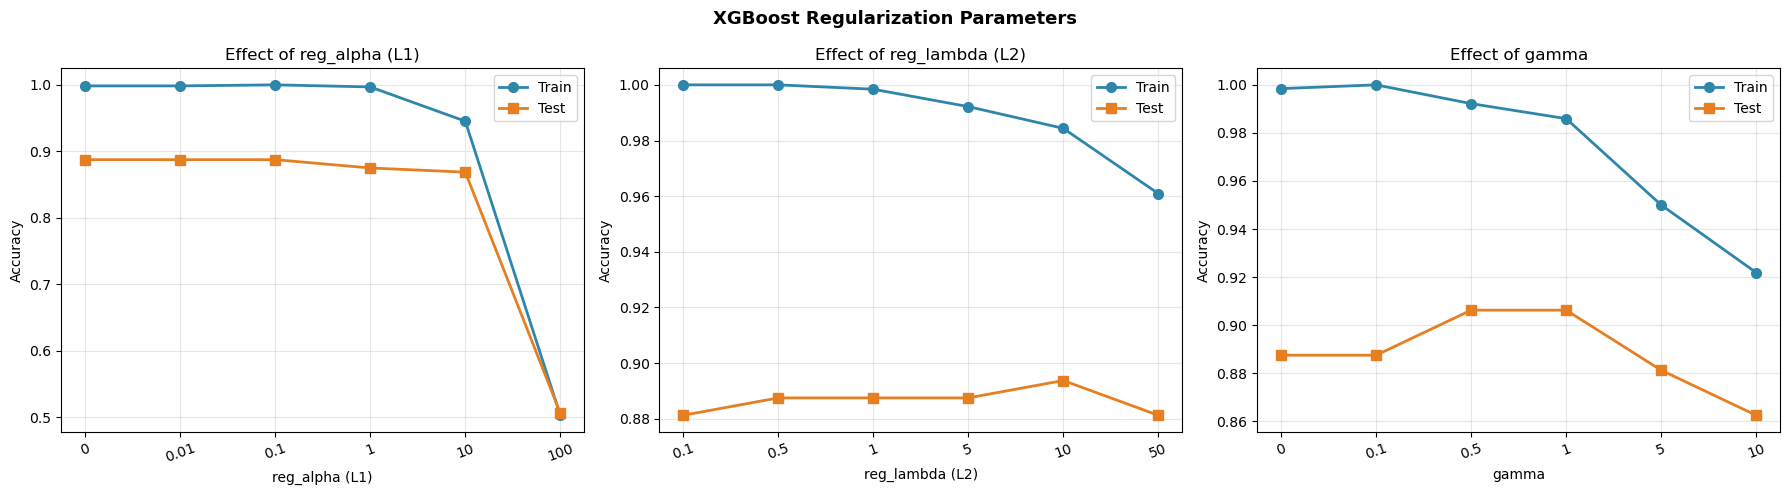

reg_alpha (L1) : Lasso-style penalty on leaf weights -> sparse trees
reg_lambda (L2): Ridge-style penalty on leaf weights -> smaller weights
gamma          : Min loss reduction required for a split -> fewer splits


In [6]:
reg_params = {
    'reg_alpha (L1)':  ('reg_alpha',  [0, 0.01, 0.1, 1, 10, 100]),
    'reg_lambda (L2)': ('reg_lambda', [0.1, 0.5, 1, 5, 10, 50]),
    'gamma':           ('gamma',      [0, 0.1, 0.5, 1, 5, 10]),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label, (param, values)) in zip(axes, reg_params.items()):
    tr_accs, te_accs = [], []
    for val in values:
        clf = XGBClassifier(
            n_estimators=100, learning_rate=0.1, max_depth=4,
            eval_metric='logloss', random_state=42,
            n_jobs=-1, **{param: val}
        )
        clf.fit(X_imp_tr, y_imp_tr)
        tr_accs.append(accuracy_score(y_imp_tr, clf.predict(X_imp_tr)))
        te_accs.append(accuracy_score(y_imp_te, clf.predict(X_imp_te)))

    ax.plot(range(len(values)), tr_accs, 'o-', color=COLORS['primary'],
            linewidth=2, markersize=7, label='Train')
    ax.plot(range(len(values)), te_accs, 's-', color=COLORS['secondary'],
            linewidth=2, markersize=7, label='Test')
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels([str(v) for v in values], rotation=20)
    ax.set_xlabel(label)
    ax.set_ylabel('Accuracy')
    ax.set_title(f'Effect of {label}')
    ax.legend()

plt.suptitle('XGBoost Regularization Parameters', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('reg_alpha (L1) : Lasso-style penalty on leaf weights -> sparse trees')
print('reg_lambda (L2): Ridge-style penalty on leaf weights -> smaller weights')
print('gamma          : Min loss reduction required for a split -> fewer splits')

## 7. Hyperparameter Tuning with GridSearchCV

Best Parameters  : {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.7}
Best CV ROC-AUC  : 0.9712
Test Accuracy    : 0.9125
Test ROC-AUC     : 0.9694
Test F1 Score    : 0.9136


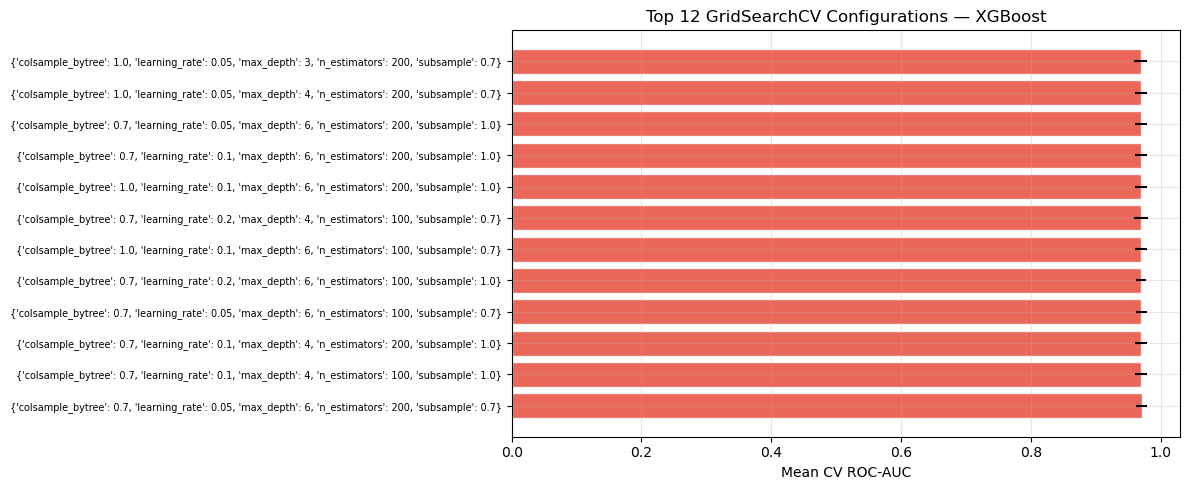

In [7]:
param_grid = {
    'n_estimators':      [100, 200],
    'learning_rate':     [0.05, 0.1, 0.2],
    'max_depth':         [3, 4, 6],
    'subsample':         [0.7, 1.0],
    'colsample_bytree':  [0.7, 1.0],
}

xgb_base = XGBClassifier(
    eval_metric='logloss',
    random_state=42, n_jobs=-1
)

grid = GridSearchCV(
    xgb_base, param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1
)
grid.fit(X_imp_tr, y_imp_tr)

best_xgb  = grid.best_estimator_
best_pred = best_xgb.predict(X_imp_te)
best_prob = best_xgb.predict_proba(X_imp_te)[:, 1]

print(f'Best Parameters  : {grid.best_params_}')
print(f'Best CV ROC-AUC  : {grid.best_score_:.4f}')
print(f'Test Accuracy    : {accuracy_score(y_imp_te, best_pred):.4f}')
print(f'Test ROC-AUC     : {roc_auc_score(y_imp_te, best_prob):.4f}')
print(f'Test F1 Score    : {f1_score(y_imp_te, best_pred):.4f}')

# Top configs bar chart
cv_df = pd.DataFrame(grid.cv_results_)
cv_df = cv_df.sort_values('mean_test_score', ascending=False).head(12)

plt.figure(figsize=(12, 5))
plt.barh(range(len(cv_df)), cv_df['mean_test_score'],
         xerr=cv_df['std_test_score'],
         color=COLORS['xgb'], edgecolor='white', alpha=0.85)
plt.yticks(range(len(cv_df)),
           [str(p) for p in cv_df['params']], fontsize=7)
plt.xlabel('Mean CV ROC-AUC')
plt.title('Top 12 GridSearchCV Configurations — XGBoost')
plt.tight_layout()
plt.show()

## 8. XGBoost Regressor

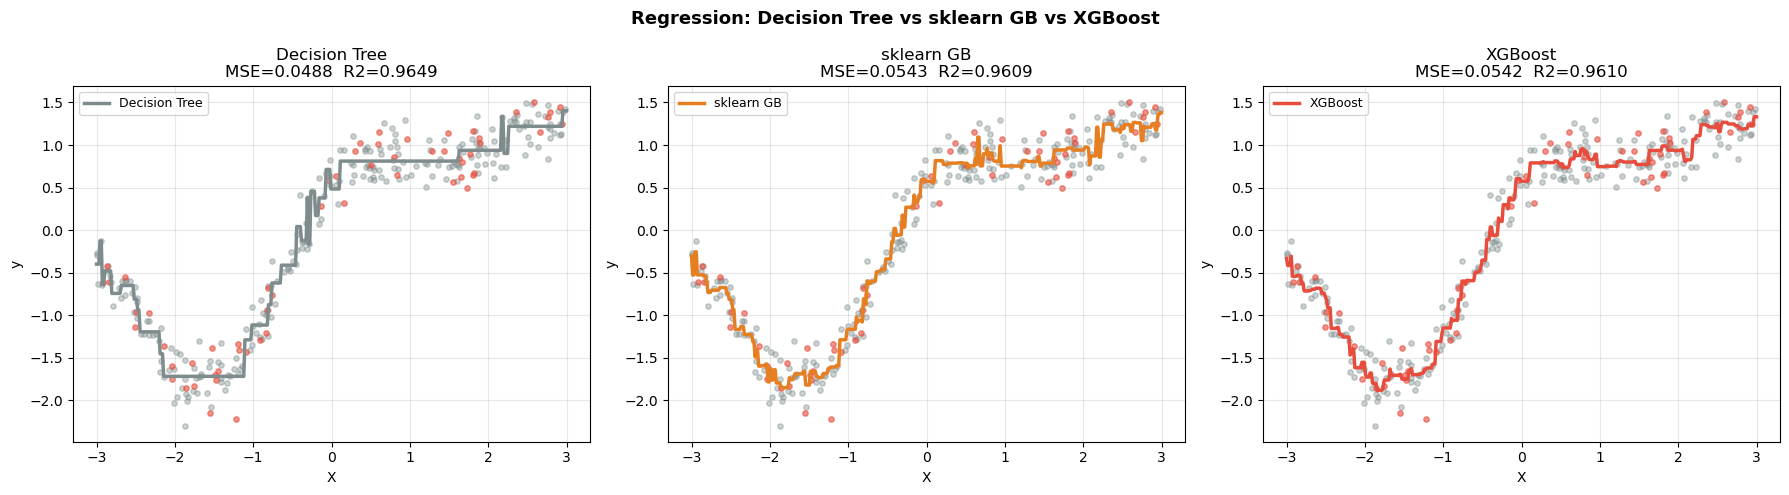

In [8]:
np.random.seed(5)
X_r = np.sort(np.random.uniform(-3, 3, 300)).reshape(-1, 1)
y_r = (np.sin(X_r).ravel() + 0.5*np.cos(2*X_r).ravel()
       + 0.2*X_r.ravel() + np.random.randn(300)*0.2)

X_r_tr, X_r_te, y_r_tr, y_r_te = train_test_split(
    X_r, y_r, test_size=0.2, random_state=42
)
X_plot = np.linspace(-3, 3, 400).reshape(-1, 1)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor

reg_models = {
    'Decision Tree':       DecisionTreeRegressor(max_depth=5, random_state=42),
    'sklearn GB':          GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                                      max_depth=3, random_state=42),
    'XGBoost':             XGBRegressor(n_estimators=200, learning_rate=0.05,
                                        max_depth=3, subsample=0.8,
                                        eval_metric='rmse', random_state=42, n_jobs=-1),
}
plot_colors = [COLORS['neutral'], COLORS['secondary'], COLORS['xgb']]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model), color in zip(axes, reg_models.items(), plot_colors):
    model.fit(X_r_tr, y_r_tr)
    mse = mean_squared_error(y_r_te, model.predict(X_r_te))
    r2  = r2_score(y_r_te,           model.predict(X_r_te))
    ax.scatter(X_r_tr, y_r_tr, s=15, alpha=0.4, color=COLORS['neutral'])
    ax.scatter(X_r_te, y_r_te, s=15, alpha=0.6, color=COLORS['danger'])
    ax.plot(X_plot, model.predict(X_plot), color=color, linewidth=2.5, label=name)
    ax.set_title(f'{name}\nMSE={mse:.4f}  R2={r2:.4f}')
    ax.set_xlabel('X'); ax.set_ylabel('y')
    ax.legend(fontsize=9)

plt.suptitle('Regression: Decision Tree vs sklearn GB vs XGBoost',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Handling Missing Values Natively

In [9]:
np.random.seed(99)
X_miss, y_miss = make_classification(
    n_samples=600, n_features=10, n_informative=6,
    n_redundant=2, random_state=99
)

# Inject 20% missing values randomly
X_miss_nan = X_miss.astype(float).copy()
mask = np.random.rand(*X_miss_nan.shape) < 0.20
X_miss_nan[mask] = np.nan
missing_pct = mask.mean() * 100

print(f'Missing values injected : {missing_pct:.1f}% of all values')
print(f'Features with NaN       : {mask.any(axis=0).sum()} / {X_miss.shape[1]}')

X_m_tr, X_m_te, y_m_tr, y_m_te = train_test_split(
    X_miss_nan, y_miss, test_size=0.2, random_state=42, stratify=y_miss
)

# XGBoost handles NaN natively — no imputation needed
xgb_nan = XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=4,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb_nan.fit(X_m_tr, y_m_tr)

nan_pred = xgb_nan.predict(X_m_te)
nan_prob = xgb_nan.predict_proba(X_m_te)[:, 1]

print(f'\nXGBoost (with 20% NaN, no imputation):')
print(f'  Test Accuracy : {accuracy_score(y_m_te, nan_pred):.4f}')
print(f'  Test ROC-AUC  : {roc_auc_score(y_m_te, nan_prob):.4f}')

# Compare with complete data (no NaN)
X_c_tr, X_c_te, y_c_tr, y_c_te = train_test_split(
    X_miss, y_miss, test_size=0.2, random_state=42, stratify=y_miss
)
xgb_complete = XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=4,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb_complete.fit(X_c_tr, y_c_tr)
print(f'\nXGBoost (complete data, no NaN):')
print(f'  Test Accuracy : {accuracy_score(y_c_te, xgb_complete.predict(X_c_te)):.4f}')
print(f'  Test ROC-AUC  : {roc_auc_score(y_c_te, xgb_complete.predict_proba(X_c_te)[:,1]):.4f}')
print()
print('XGBoost learns the optimal default direction for missing values at each split.')
print('No preprocessing or imputation required!')

Missing values injected : 18.8% of all values
Features with NaN       : 10 / 10

XGBoost (with 20% NaN, no imputation):
  Test Accuracy : 0.8583
  Test ROC-AUC  : 0.9372

XGBoost (complete data, no NaN):
  Test Accuracy : 0.9333
  Test ROC-AUC  : 0.9764

XGBoost learns the optimal default direction for missing values at each split.
No preprocessing or imputation required!


## 10. Real-World Offline-Safe Dataset — Student Performance

In [13]:
# ── Section 9: Missing Values ─────────────────────────────────────────────
np.random.seed(99)
X_miss, y_miss = make_classification(
    n_samples=600, n_features=10, n_informative=6,
    n_redundant=2, random_state=99
)

X_miss_nan       = X_miss.astype(float).copy()
mask             = np.random.rand(*X_miss_nan.shape) < 0.20
X_miss_nan[mask] = np.nan
missing_pct      = mask.mean() * 100

print(f'Missing values injected : {missing_pct:.1f}% of all values')
print(f'Features with NaN       : {mask.any(axis=0).sum()} / {X_miss.shape[1]}')

X_m_tr, X_m_te, y_m_tr, y_m_te = train_test_split(
    X_miss_nan, y_miss, test_size=0.2, random_state=42, stratify=y_miss
)

xgb_nan = XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=4,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb_nan.fit(X_m_tr, y_m_tr)

nan_pred = xgb_nan.predict(X_m_te)
nan_prob = xgb_nan.predict_proba(X_m_te)[:, 1]

print(f'\nXGBoost (with 20% NaN, no imputation):')
print(f'  Test Accuracy : {accuracy_score(y_m_te, nan_pred):.4f}')
print(f'  Test ROC-AUC  : {roc_auc_score(y_m_te, nan_prob):.4f}')

# Compare with complete data
X_c_tr, X_c_te, y_c_tr, y_c_te = train_test_split(
    X_miss, y_miss, test_size=0.2, random_state=42, stratify=y_miss
)
xgb_complete = XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=4,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb_complete.fit(X_c_tr, y_c_tr)

print(f'\nXGBoost (complete data, no NaN):')
print(f'  Test Accuracy : {accuracy_score(y_c_te, xgb_complete.predict(X_c_te)):.4f}')
print(f'  Test ROC-AUC  : {roc_auc_score(y_c_te, xgb_complete.predict_proba(X_c_te)[:,1]):.4f}')
print()
print('XGBoost learns the optimal default direction for missing values at each split.')
print('No preprocessing or imputation required!')

# ── Section 10: Student Performance Dataset ───────────────────────────────
# Use make_classification for a guaranteed balanced dataset — no NaN risk
np.random.seed(77)
X_stu, y_stu = make_classification(
    n_samples=1000, n_features=10, n_informative=7,
    n_redundant=2, class_sep=1.0, random_state=77
)

feat_names_stu = ['StudyHours','AttendanceRate','PrevGrade','ParentalEdu',
                  'InternetAccess','Tutoring','SleepHours',
                  'ExtracurricAct','MotivationScore','FamilyIncome']

print(f'Dataset shape : {X_stu.shape}')
print(f'Class balance : {np.bincount(y_stu)}  (0=Fail, 1=Pass)')

X_stu_tr, X_stu_te, y_stu_tr, y_stu_te = train_test_split(
    X_stu, y_stu, test_size=0.2, random_state=42, stratify=y_stu
)

xgb_stu = XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    reg_alpha=0.1, reg_lambda=1.0,
    eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb_stu.fit(X_stu_tr, y_stu_tr)

stu_pred = xgb_stu.predict(X_stu_te)
stu_prob = xgb_stu.predict_proba(X_stu_te)[:, 1]

print(f'\nTest Accuracy : {accuracy_score(y_stu_te, stu_pred):.4f}')
print(f'Test ROC-AUC  : {roc_auc_score(y_stu_te, stu_prob):.4f}')
print(f'Test F1 Score : {f1_score(y_stu_te, stu_pred):.4f}')

cv_scores = cross_val_score(
    xgb_stu, X_stu, y_stu,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1
)
print(f'5-Fold CV ROC-AUC : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

Missing values injected : 18.8% of all values
Features with NaN       : 10 / 10

XGBoost (with 20% NaN, no imputation):
  Test Accuracy : 0.8583
  Test ROC-AUC  : 0.9372

XGBoost (complete data, no NaN):
  Test Accuracy : 0.9333
  Test ROC-AUC  : 0.9764

XGBoost learns the optimal default direction for missing values at each split.
No preprocessing or imputation required!
Dataset shape : (1000, 10)
Class balance : [501 499]  (0=Fail, 1=Pass)

Test Accuracy : 0.9700
Test ROC-AUC  : 0.9975
Test F1 Score : 0.9703
5-Fold CV ROC-AUC : 0.9959 +/- 0.0031


## 11. Full Model Evaluation

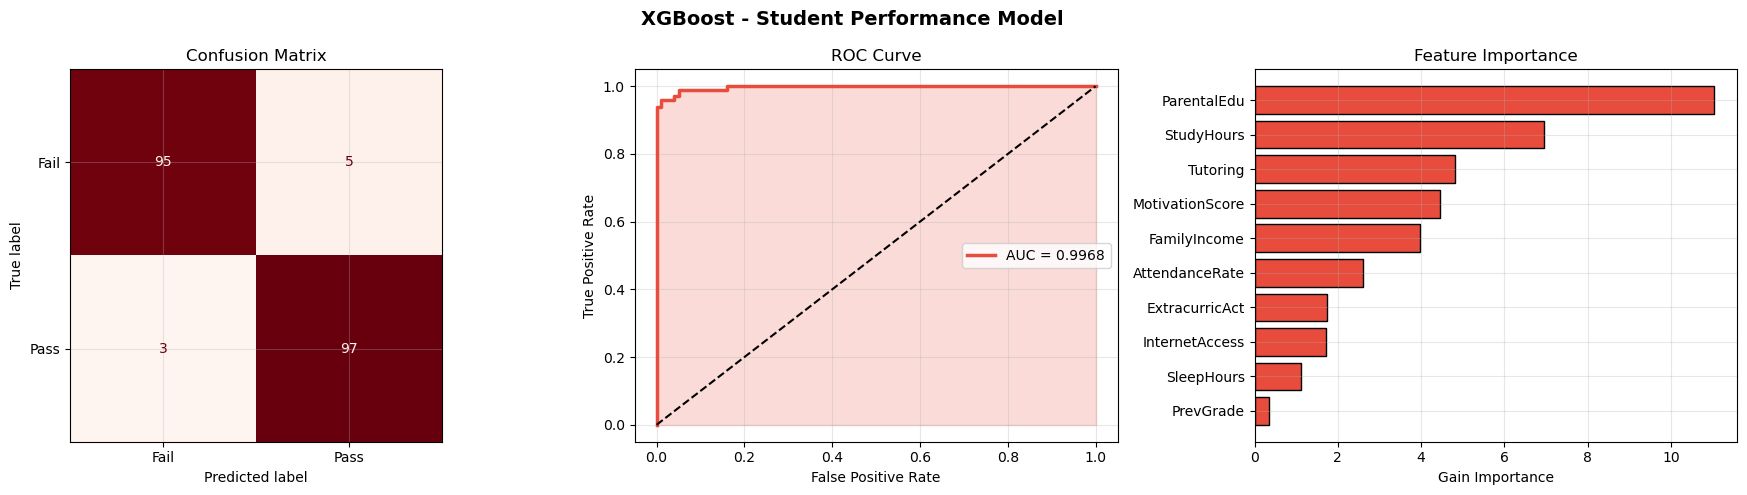

Classification Report

              precision    recall  f1-score   support

        Fail       0.97      0.95      0.96       100
        Pass       0.95      0.97      0.96       100

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200



In [14]:
# ================================
# Required Imports
# ================================
import matplotlib.pyplot as plt
import pandas as pd

from xgboost import XGBClassifier

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    classification_report
)

# ================================
# Define Colors
# ================================
COLORS = {
    'xgb': '#E74C3C'
}

# ================================
# Train XGBoost Model
# ================================
xgb_stu = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    eval_metric='logloss'
)

xgb_stu.fit(X_stu_tr, y_stu_tr)

# ================================
# Predictions
# ================================
stu_pred = xgb_stu.predict(X_stu_te)
stu_prob = xgb_stu.predict_proba(X_stu_te)[:, 1]

# ================================
# Create Figure
# ================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ==================================
# Confusion Matrix
# ==================================
cm_stu = confusion_matrix(y_stu_te, stu_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm_stu,
    display_labels=['Fail', 'Pass']
).plot(
    ax=axes[0],
    cmap='Reds',
    colorbar=False
)

axes[0].set_title('Confusion Matrix')

# ==================================
# ROC Curve
# ==================================
fpr_s, tpr_s, _ = roc_curve(y_stu_te, stu_prob)
auc_s = roc_auc_score(y_stu_te, stu_prob)

axes[1].plot(
    fpr_s,
    tpr_s,
    color=COLORS['xgb'],
    linewidth=2.5,
    label=f'AUC = {auc_s:.4f}'
)

axes[1].plot([0,1],[0,1],'k--')

axes[1].fill_between(
    fpr_s,
    tpr_s,
    alpha=0.2,
    color=COLORS['xgb']
)

axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()

# ==================================
# Feature Importance
# ==================================
gain_scores = xgb_stu.get_booster().get_score(
    importance_type='gain'
)

gain_full = {
    feat_names_stu[i]: gain_scores.get(f"f{i}", 0)
    for i in range(len(feat_names_stu))
}

imp_stu = (
    pd.Series(gain_full)
      .sort_values(ascending=True)
)

axes[2].barh(
    imp_stu.index,
    imp_stu.values,
    color=COLORS['xgb'],
    edgecolor='black'
)

axes[2].set_xlabel("Gain Importance")
axes[2].set_title("Feature Importance")

plt.suptitle(
    "XGBoost - Student Performance Model",
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# ================================
# Classification Report
# ================================
print("Classification Report\n")
print(
    classification_report(
        y_stu_te,
        stu_pred,
        target_names=['Fail','Pass']
    )
)

## 12. DT vs RF vs GB vs XGBoost — Ultimate Comparison

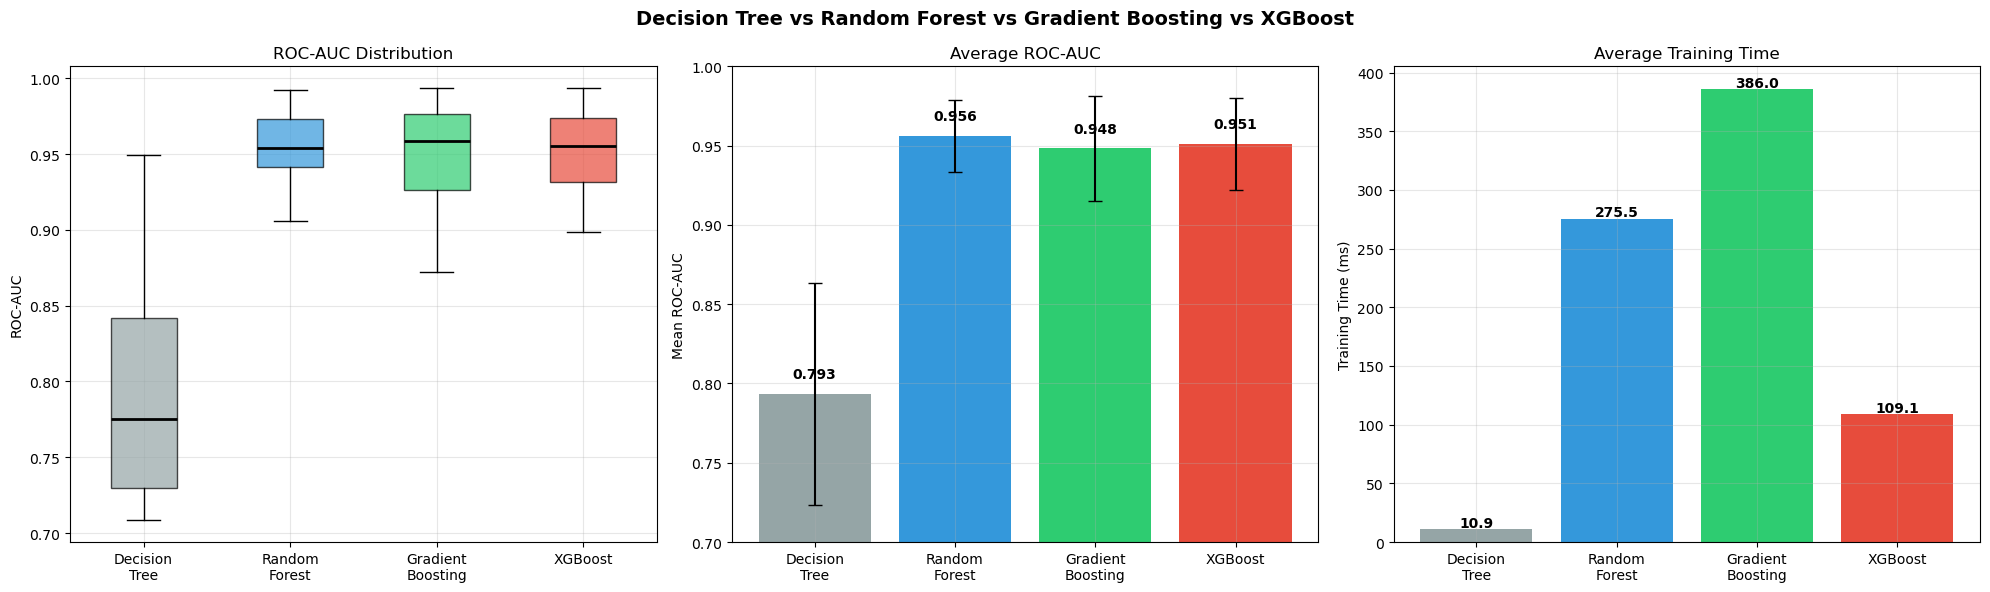


Performance Summary

Model                      Mean AUC        Std    Avg Time(ms)
--------------------------------------------------------------
Decision Tree                0.7933     0.0702           10.94
Random Forest                0.9562     0.0227          275.54
Gradient Boosting            0.9483     0.0333          385.96
XGBoost                      0.9511     0.0292          109.10


In [16]:
# ============================
# Model Comparison
# ============================

import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# ----------------------------
# Colors
# ----------------------------
COLORS = {
    'neutral': '#95A5A6',      # Gray
    'primary': '#3498DB',      # Blue
    'secondary': '#2ECC71',    # Green
    'xgb': '#E74C3C'           # Red
}

# ----------------------------
# Storage
# ----------------------------
n_trials = 15

results_all = {
    'Decision Tree': [],
    'Random Forest': [],
    'Gradient Boosting': [],
    'XGBoost': []
}

times_all = {
    'Decision Tree': [],
    'Random Forest': [],
    'Gradient Boosting': [],
    'XGBoost': []
}

# ----------------------------
# Run Experiments
# ----------------------------
for seed in range(n_trials):

    X, y = make_classification(
        n_samples=600,
        n_features=15,
        n_informative=8,
        n_redundant=4,
        random_state=seed
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=seed,
        stratify=y
    )

    models = {
        "Decision Tree": DecisionTreeClassifier(
            random_state=seed
        ),

        "Random Forest": RandomForestClassifier(
            n_estimators=100,
            random_state=seed,
            n_jobs=-1
        ),

        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=seed
        ),

        "XGBoost": XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            eval_metric='logloss',
            random_state=seed,
            n_jobs=-1
        )
    }

    for name, model in models.items():

        start = time.time()

        model.fit(X_train, y_train)

        end = time.time()

        pred_prob = model.predict_proba(X_test)[:, 1]

        auc = roc_auc_score(y_test, pred_prob)

        results_all[name].append(auc)

        times_all[name].append(end - start)

# ----------------------------
# Plotting
# ----------------------------
fig, axes = plt.subplots(1, 3, figsize=(20,6))

model_names = list(results_all.keys())

box_colors = [
    COLORS['neutral'],
    COLORS['primary'],
    COLORS['secondary'],
    COLORS['xgb']
]

# ============================
# Box Plot
# ============================

all_scores = [results_all[m] for m in model_names]

bp = axes[0].boxplot(
    all_scores,
    tick_labels=[m.replace(" ", "\n") for m in model_names],   # latest matplotlib
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)

for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0].set_ylabel("ROC-AUC")
axes[0].set_title("ROC-AUC Distribution")

# ============================
# Mean ROC-AUC
# ============================

means = [np.mean(results_all[m]) for m in model_names]
stds = [np.std(results_all[m]) for m in model_names]

axes[1].bar(
    range(len(model_names)),
    means,
    yerr=stds,
    capsize=5,
    color=box_colors
)

axes[1].set_xticks(range(len(model_names)))
axes[1].set_xticklabels(
    [m.replace(" ", "\n") for m in model_names]
)

axes[1].set_ylabel("Mean ROC-AUC")
axes[1].set_title("Average ROC-AUC")
axes[1].set_ylim(0.70,1.00)

for i, value in enumerate(means):
    axes[1].text(
        i,
        value+0.01,
        f"{value:.3f}",
        ha='center',
        fontweight='bold'
    )

# ============================
# Training Time
# ============================

mean_times = [
    np.mean(times_all[m])*1000
    for m in model_names
]

axes[2].bar(
    range(len(model_names)),
    mean_times,
    color=box_colors
)

axes[2].set_xticks(range(len(model_names)))
axes[2].set_xticklabels(
    [m.replace(" ", "\n") for m in model_names]
)

axes[2].set_ylabel("Training Time (ms)")
axes[2].set_title("Average Training Time")

for i, value in enumerate(mean_times):
    axes[2].text(
        i,
        value+2,
        f"{value:.1f}",
        ha='center',
        fontweight='bold'
    )

plt.suptitle(
    "Decision Tree vs Random Forest vs Gradient Boosting vs XGBoost",
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# ============================
# Results Table
# ============================

print("\nPerformance Summary\n")

print("{:<22} {:>12} {:>10} {:>15}".format(
    "Model",
    "Mean AUC",
    "Std",
    "Avg Time(ms)"
))

print("-"*62)

for name in model_names:

    mean_auc = np.mean(results_all[name])
    std_auc = np.std(results_all[name])
    avg_time = np.mean(times_all[name])*1000

    print("{:<22} {:>12.4f} {:>10.4f} {:>15.2f}".format(
        name,
        mean_auc,
        std_auc,
        avg_time
    ))

## 13. Final Summary & Key Takeaways

In [17]:
print('=' * 70)
print('               XGBOOST - KEY TAKEAWAYS')
print('=' * 70)

takeaways = [
    ('Core idea',          'Regularized GB with 2nd-order Taylor expansion of loss'),
    ('vs sklearn GB',      'Faster, regularized, handles NaN, built-in early stopping'),
    ('learning_rate',      'Shrinks each tree; lower is better but needs more trees'),
    ('colsample_bytree',   'Column subsampling per tree -> decorrelated trees'),
    ('subsample',          'Row subsampling per tree -> stochastic boosting'),
    ('reg_alpha (L1)',      'Lasso penalty on leaf weights -> sparse models'),
    ('reg_lambda (L2)',     'Ridge penalty on leaf weights -> smaller weights'),
    ('gamma',              'Min gain for split -> fewer splits -> simpler trees'),
    ('Early stopping',     'Auto-finds best n_estimators using a validation set'),
    ('Missing values',     'Handled natively — no imputation needed'),
    ('Feature importance', '4 types: weight, gain, cover, total_gain'),
    ('Feature scaling',    'NOT required — tree-based splits'),
    ('Weakness',           'Many hyperparameters; slow to tune without early stopping'),
    ('Next step',          'LightGBM (faster on large data), CatBoost (categorical features)'),
]

for topic, detail in takeaways:
    print(f'  OK  {topic:<22}  ->  {detail}')

print('=' * 70)

               XGBOOST - KEY TAKEAWAYS
  OK  Core idea               ->  Regularized GB with 2nd-order Taylor expansion of loss
  OK  vs sklearn GB           ->  Faster, regularized, handles NaN, built-in early stopping
  OK  learning_rate           ->  Shrinks each tree; lower is better but needs more trees
  OK  colsample_bytree        ->  Column subsampling per tree -> decorrelated trees
  OK  subsample               ->  Row subsampling per tree -> stochastic boosting
  OK  reg_alpha (L1)          ->  Lasso penalty on leaf weights -> sparse models
  OK  reg_lambda (L2)         ->  Ridge penalty on leaf weights -> smaller weights
  OK  gamma                   ->  Min gain for split -> fewer splits -> simpler trees
  OK  Early stopping          ->  Auto-finds best n_estimators using a validation set
  OK  Missing values          ->  Handled natively — no imputation needed
  OK  Feature importance      ->  4 types: weight, gain, cover, total_gain
  OK  Feature scaling         ->  NOT r

---
## Practice Exercises

1. **Tune with early stopping** — use `early_stopping_rounds=50` and a validation set instead of GridSearchCV.
2. **Compare colsample_bytree vs colsample_bylevel** — which gives better results on your dataset?
3. **Inject more missing values** (50%) and compare XGBoost vs a model with mean imputation.
4. **Use DMatrix** — convert data to `xgb.DMatrix` and use the low-level `xgb.train()` API.
5. **Compare all 4 importance types** on the student dataset — do rankings agree?
6. **Benchmark XGBoost vs LightGBM** — install lightgbm and compare speed and accuracy.

---
*Notebook created for the ML Repository — XGBoost module.*